# Physical Basis of Sea Ice Concentration Observations

This notebook introduces the physical basis for satellite sea ice observations.

By the end of this notebook, you should be able to:

- Explain the physical basis of passive microwave sea ice products and their limitations.
- Define common sea ice metrics, including extent, area, concentration, thickness, freeboard, and age.
- Describe why microwave brightness temperature differs between open water, first-year sea ice, and multi-year sea ice.

## 1. Why Observe Sea Ice from Space?

Sea ice is a major indicator of polar climate change. Changes in sea ice cover affect Earth's albedo, air-sea heat exchange, polar ecosystems, ocean circulation, and human activity in polar regions.

Satellite observations are essential because sea ice changes rapidly, covers remote regions, and varies over very large spatial scales. Passive microwave observations are especially useful because they can be collected during polar night and through most cloud cover.

Sea ice conditions are influenced by several physical factors:

- Air temperature
- Sea surface temperature
- Sea surface salinity
- Ocean circulation
- Surface wind stress
- Snow cover and melt ponds

## 2. What Is Sea Ice?

**Sea ice** is frozen seawater. It forms when the ocean surface cools enough for ice crystals to develop and consolidate. In polar regions, sea ice expands during winter and retreats during summer.

Sea ice is not the same thing as land ice. The following are **not** sea ice:

- Ice sheets
- Ice shelves
- Glaciers
- Icebergs
- Ice caps
- Snow
- Ice mélange, although it can be mixed with sea ice in some coastal or fjord environments

A useful reminder: sea ice forms from the ocean, while glaciers and ice sheets form from compacted snowfall on land.

## 3. Sea Ice Metrics

Satellite products can describe several different properties of sea ice.

| Metric | Definition | Common units | Notes |
|---|---|---:|---|
| Sea ice concentration | Fraction of an area covered by sea ice | 0-1 or % | Most common passive microwave product |
| Sea ice area | Total ice-covered area accounting for concentration | km$^2$ | Sum of grid cell area multiplied by concentration |
| Sea ice extent | Area of grid cells with concentration above a threshold, often 15% | km$^2$ | Useful for long-term climate monitoring |
| Sea ice thickness | Vertical thickness of ice | m | Difficult to measure directly from space |
| Sea ice freeboard | Height of ice/snow surface above the waterline | m | Used to estimate thickness from altimetry |
| Sea ice age | Time since formation | years | Often grouped as first-year or multi-year ice |

### Concentration, Area, and Extent

Sea ice **concentration** describes how much of a grid cell is covered by ice. For example, a grid cell with concentration 0.90 is about 90% ice-covered.

Sea ice **area** and **extent** are related but not identical:

\[
\text{area} = \sum_i A_i C_i
\]

where $A_i$ is grid cell area and $C_i$ is concentration.

Sea ice **extent** typically counts the full area of all grid cells where concentration exceeds a threshold, often 15%:

\[
\text{extent} = \sum_i A_i \quad \text{where} \quad C_i \ge 0.15
\]

This means sea ice extent is usually larger than sea ice area.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example grid cells with equal area
cell_area_km2 = 25 * 25  # 25 km x 25 km grid cell
concentration = np.array([0.92, 0.80, 0.55, 0.20, 0.10, 0.00])

area = np.sum(cell_area_km2 * concentration)
extent = np.sum(cell_area_km2 * (concentration >= 0.15))

summary = pd.DataFrame({
    'grid_cell': np.arange(1, len(concentration)+1),
    'concentration': concentration,
    'cell_area_km2': cell_area_km2,
    'ice_area_km2': cell_area_km2 * concentration,
    'counts_toward_extent': concentration >= 0.15
})

summary, area, extent

(   grid_cell  concentration  cell_area_km2  ice_area_km2  counts_toward_extent
 0          1           0.92            625        575.00                  True
 1          2           0.80            625        500.00                  True
 2          3           0.55            625        343.75                  True
 3          4           0.20            625        125.00                  True
 4          5           0.10            625         62.50                 False
 5          6           0.00            625          0.00                 False,
 np.float64(1606.25),
 np.int64(2500))

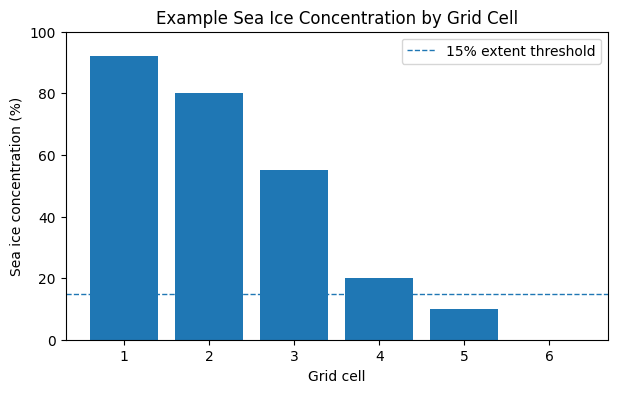

Sea ice area = 1606 km^2
Sea ice extent = 2500 km^2


In [2]:
plt.figure(figsize=(7, 4))
plt.bar(summary['grid_cell'], summary['concentration'] * 100)
plt.axhline(15, linestyle='--', linewidth=1, label='15% extent threshold')
plt.xlabel('Grid cell')
plt.ylabel('Sea ice concentration (%)')
plt.title('Example Sea Ice Concentration by Grid Cell')
plt.ylim(0, 100)
plt.legend()
plt.show()

print(f'Sea ice area = {area:.0f} km^2')
print(f'Sea ice extent = {extent:.0f} km^2')

### Check Your Understanding

In the example above, why is sea ice extent larger than sea ice area? What would happen to extent if the threshold changed from 15% to 30%?

## 4. First-Year and Multi-Year Sea Ice

**First-year sea ice** is newly formed ice that has not survived a summer melt season. It is usually thinner, saltier, and less weathered.

**Multi-year sea ice** has survived at least one melt season. It is typically thicker and fresher because brine is gradually expelled from the ice over time. Multi-year ice can also contain air bubbles, snow cover, and melt ponds.

These physical differences matter because satellite microwave measurements respond strongly to emissivity, salinity, temperature, roughness, snow cover, and liquid water on the surface.

## 5. Brightness Temperature and Emissivity

Passive microwave sensors measure the natural microwave emission from the surface. The observed signal is often expressed as **brightness temperature**, $T_B$.

A simple first-order approximation is:

\[
T_B = eT
\]

where:

- $T_B$ is brightness temperature in kelvin.
- $e$ is emissivity, the fraction of blackbody emission produced by the surface.
- $T$ is the physical temperature of the emitting surface in kelvin.

This simple equation is not a complete satellite retrieval model, but it captures the key idea: surfaces with different emissivities can have different brightness temperatures even if their physical temperatures are similar.

In [3]:
T_surface = 265  # K, representative cold polar surface temperature
surfaces = pd.DataFrame({
    'surface': ['Open water', 'First-year ice', 'Multi-year ice'],
    'example_emissivity': [0.50, 0.95, 0.75]
})
surfaces['brightness_temperature_K'] = surfaces['example_emissivity'] * T_surface
surfaces

,surface,example_emissivity,brightness_temperature_K
0,Open water,0.50,132.50
1,First-year ice,0.95,251.75
2,Multi-year ice,0.75,198.75


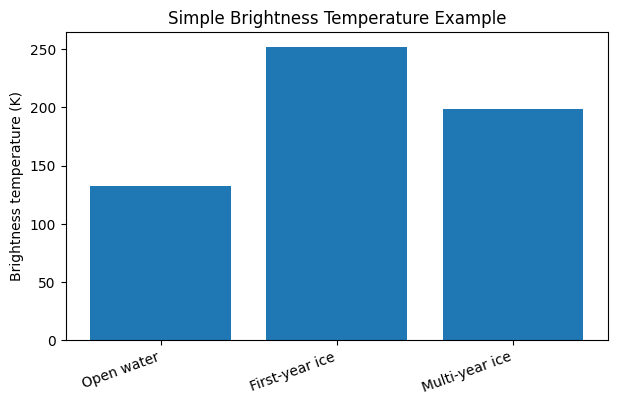

In [4]:
plt.figure(figsize=(7, 4))
plt.bar(surfaces['surface'], surfaces['brightness_temperature_K'])
plt.ylabel('Brightness temperature (K)')
plt.title('Simple Brightness Temperature Example')
plt.ylim(0, T_surface)
plt.xticks(rotation=20, ha='right')
plt.show()

## 6. Why Use Microwaves for Sea Ice?

Passive microwave observations are useful for sea ice because ice and open water have distinct microwave emissivities. These differences are large enough that sea ice concentration can often be estimated even when the atmosphere, ionosphere, and cosmic background add noise.

Microwave observations also work during polar night and through most clouds, which is essential for year-round monitoring in polar regions.

However, microwave retrievals still have limitations. Weather, water vapor, thin ice, mixed pixels, melt ponds, and ice edge conditions can all increase uncertainty.

## 7. Frequency Dependence of Microwave Emission

Different surfaces have different emissivity spectra:

- Fresh or first-year ice often has high emissivity that is nearly constant across common sea ice frequencies.
- Open water has lower emissivity and strong polarization dependence.
- Multi-year ice can have a different frequency dependence because of lower salinity, air bubbles, snow, and internal scattering.

The exact values vary with temperature, salinity, roughness, snow, melt, and viewing geometry. The curves below are schematic and are intended to show the conceptual separation between surface types.

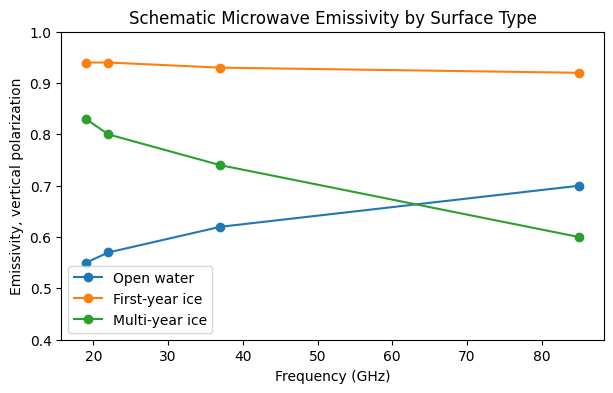

In [5]:
freq = np.array([19, 22, 37, 85])  # GHz, common passive microwave frequencies

# Schematic emissivity curves for illustration only
open_water_v = np.array([0.55, 0.57, 0.62, 0.70])
first_year_v = np.array([0.94, 0.94, 0.93, 0.92])
multi_year_v = np.array([0.83, 0.80, 0.74, 0.60])

plt.figure(figsize=(7, 4))
plt.plot(freq, open_water_v, marker='o', label='Open water')
plt.plot(freq, first_year_v, marker='o', label='First-year ice')
plt.plot(freq, multi_year_v, marker='o', label='Multi-year ice')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Emissivity, vertical polarization')
plt.title('Schematic Microwave Emissivity by Surface Type')
plt.ylim(0.4, 1.0)
plt.legend()
plt.show()

## 8. Polarization

Microwave sensors often measure radiation in different polarizations. For sea ice, the most common are:

- **V-polarized** radiation: electric field oscillations are oriented vertically relative to the observing geometry.
- **H-polarized** radiation: electric field oscillations are oriented horizontally relative to the observing geometry.

In general, H-polarized microwave emission from both ice and water has lower emissivity than V-polarized emission. The magnitude of the V-H difference varies by surface type, and this contrast helps algorithms distinguish open water, first-year ice, and multi-year ice.

In [6]:
# Schematic vertical and horizontal brightness temperatures at 19 and 37 GHz
examples = pd.DataFrame({
    'surface': ['Open water', 'First-year ice', 'Multi-year ice'],
    'T19V': [150, 250, 220],
    'T19H': [90, 235, 205],
    'T37V': [165, 248, 195],
    'T37H': [105, 230, 170]
})
examples

,surface,T19V,T19H,T37V,T37H
0,Open water,150,90,165,105
1,First-year ice,250,235,248,230
2,Multi-year ice,220,205,195,170


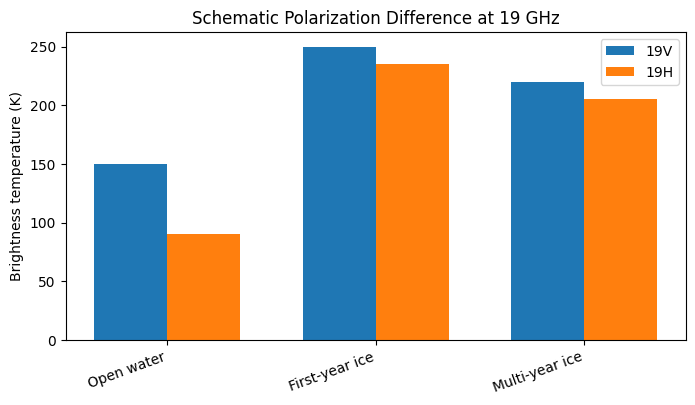

In [7]:
x = np.arange(len(examples))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, examples['T19V'], width, label='19V')
plt.bar(x + width/2, examples['T19H'], width, label='19H')
plt.xticks(x, examples['surface'], rotation=20, ha='right')
plt.ylabel('Brightness temperature (K)')
plt.title('Schematic Polarization Difference at 19 GHz')
plt.legend()
plt.show()